<a href="https://colab.research.google.com/github/KuldeepIsharwal/Machine-Learning-Basics/blob/main/handling_missing_data_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Random Imputation(Univariate) :
  we fill missing with random numbers withing the range of that coln

  adv : preserves variance of variable
  
  disadv : memory heavy for deployment , we need to store original training set for deployment so if it encounters a missing value in a feature it can fill it randomly from that data

  best part : well suited for linear models as it doesnt changes distribution regardless of % NA

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df= pd.read_csv('/content/titanic.csv',usecols = ['Fare','Survived','Age'])
df3 = df.copy()


In [9]:
df.sample(5)

,Survived,Age,Fare
278,0,7.0,29.1250
741,0,36.0,78.8500
36,1,NaN,7.2292
595,0,36.0,24.1500
243,0,22.0,7.1250


In [10]:
df.isnull().mean()

,0
Survived,0.000000
Age,0.198653
Fare,0.000000


In [14]:
updated_age = df['Age'].copy()
random_fill_values = df['Age'].dropna().sample(n=df['Age'].isnull().sum(), replace=True, random_state=42)
missing_age_indices = df[df['Age'].isnull()].index
random_fill_values.index = missing_age_indices
updated_age.loc[missing_age_indices] = random_fill_values
df['updated_age'] = updated_age

In [17]:
df.sample(5)

,Survived,Age,Fare,updated_age
856,1,45.0,164.8667,45.0
331,0,45.5,28.5000,45.5
95,0,NaN,8.0500,20.0
499,0,24.0,7.7958,24.0
441,0,20.0,9.5000,20.0


/tmp/ipykernel_686/389057728.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'],hist=False)
/tmp/ipykernel_686/389057728.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['updated_age'],hist=False)


<Axes: xlabel='updated_age', ylabel='Density'>

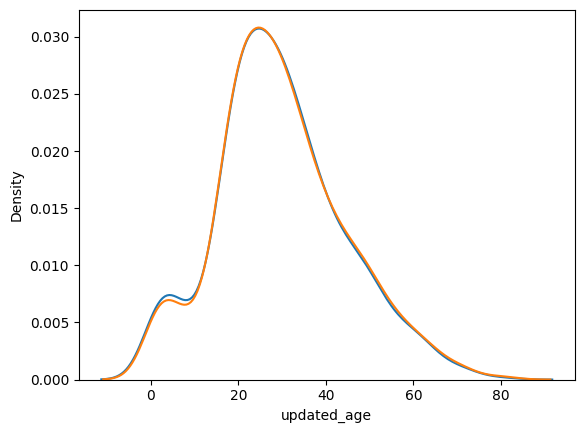

In [19]:
sns.distplot(df['Age'],hist=False)
sns.distplot(df['updated_age'],hist=False)
#

In [21]:
df['Age'].var()


211.0191247463081

In [22]:
df['updated_age'].var()

214.14682102397276

In [23]:
df.cov()

,Survived,Age,Fare,updated_age
Survived,0.236772,-0.551296,6.221787,-0.479407
Age,-0.551296,211.019125,73.849030,211.019125
Fare,6.221787,73.849030,2469.436846,43.873698
updated_age,-0.479407,211.019125,43.873698,214.146821


In [24]:
from matplotlib import use
df2 = pd.read_csv('/content/train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [26]:
df2.sample(5)

,FireplaceQu,GarageQual,SalePrice
859,Gd,TA,250000
640,Gd,TA,274000
380,Gd,TA,127000
889,TA,TA,149500
988,TA,TA,195000


In [28]:
df2.isnull().mean()

,0
FireplaceQu,0.472603
GarageQual,0.055479
SalePrice,0.000000


In [29]:
updated_GarageQual = df2['GarageQual'].copy()
random_fill_values = df2['GarageQual'].dropna().sample(n=df2['GarageQual'].isnull().sum(), replace=True, random_state=42)
missing_GarageQual_indices = df2[df2['GarageQual'].isnull()].index
random_fill_values.index = missing_GarageQual_indices
updated_GarageQual.loc[missing_GarageQual_indices] = random_fill_values
df2['updated_GarageQual'] = updated_GarageQual

In [31]:
updated_FireplaceQu = df2['FireplaceQu'].copy()
random_fill_values = df2['FireplaceQu'].dropna().sample(n=df2['FireplaceQu'].isnull().sum(), replace=True, random_state=42)
missing_FireplaceQu_indices = df2[df2['FireplaceQu'].isnull()].index
random_fill_values.index = missing_FireplaceQu_indices
updated_FireplaceQu.loc[missing_FireplaceQu_indices] = random_fill_values
df2['updated_FireplaceQu'] = updated_FireplaceQu

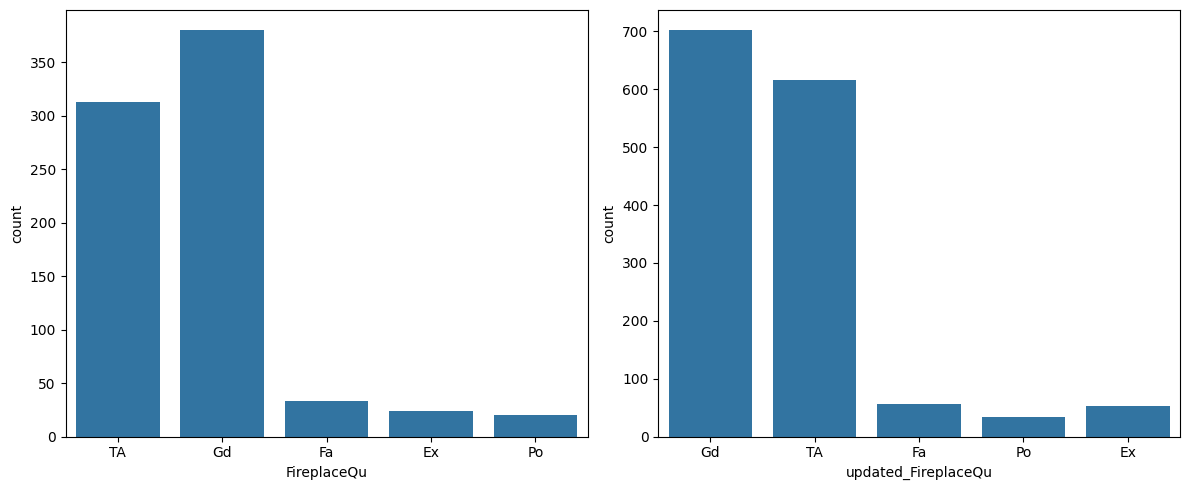

In [34]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df2, x='FireplaceQu')

plt.subplot(1, 2, 2)
sns.countplot(data=df2, x='updated_FireplaceQu')
plt.tight_layout()
plt.show()

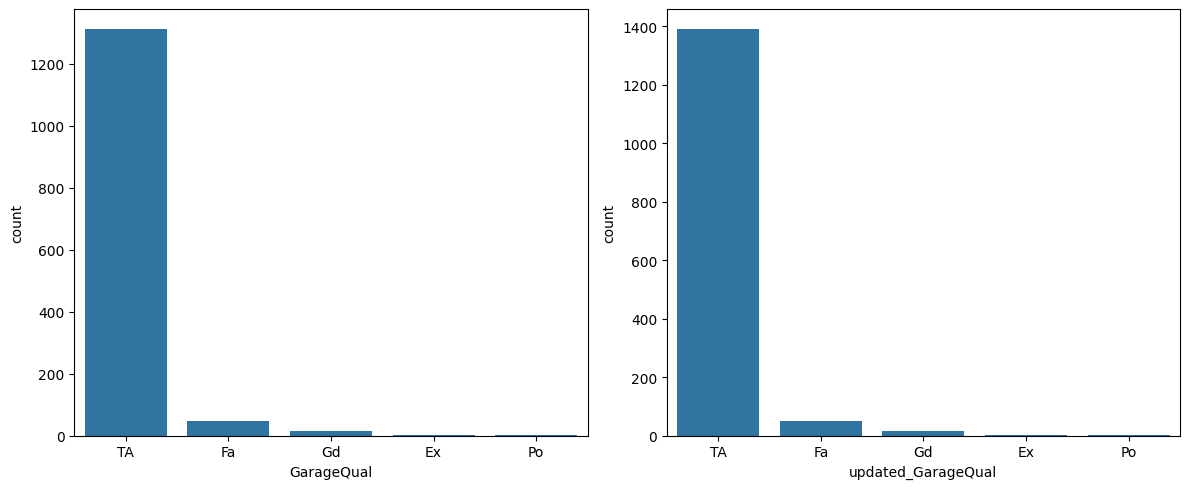

In [35]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df2, x='GarageQual')

plt.subplot(1, 2, 2)
sns.countplot(data=df2, x='updated_GarageQual')
plt.tight_layout()
plt.show()

missing indicator : make a new coln and place 0 if value is present in original coln and 1 if it missing and the impute the original coln

somehow model learns to differentiate that data was missing here

In [40]:
from sklearn.impute import MissingIndicator
mi = MissingIndicator()

In [41]:
mi.fit(df3)

MissingIndicator()

In [43]:
df3_missing = mi.transform(df3)

In [44]:
df3_missing

array([[False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

GridSearchCV (Grid Search Cross-Validation) is an automated tool provided by Scikit-Learn that solves this by systematically working through a multiple-choice menu of hyperparameter options, testing them, and pinpointing the exact combination that yields the highest accuracy.